#  India Traffic Accidents Analysis
### Course: INT375 — Data Science Toolbox: Python Programming
### Dataset: ADSI Table 1A — Road, Railway & Total Traffic Accidents
---

##  Cell 1 — Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All libraries imported successfully ')

All libraries imported successfully 


##  Cell 2 — Load Data (Pandas)


In [26]:
df_raw = pd.read_csv(r"C:\Users\atulk\Downloads\ADSI_Table_1A.2.csv")
print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(10)

Shape: (93, 14)
Columns: ['Sl. No.', 'State/UT/City', 'Road Accidents - Cases', 'Road Accidents - Injured', 'Road Accidents - Died', 'Railway Accidents - Cases', 'Railway Accidents - Injured', 'Railway Accidents - Died', 'Railway Crossing Accidents - Cases', 'Railway Crossing Accidents - Injured', 'Railway Crossing Accidents - Died', 'Total Traffic Accidents - Cases', 'Total Traffic Accidents - Injured', 'Total Traffic Accidents - Died']


,Sl. No.,State/UT/City,Road Accidents - Cases,Road Accidents - Injured,Road Accidents - Died,Railway Accidents - Cases,Railway Accidents - Injured,Railway Accidents - Died,Railway Crossing Accidents - Cases,Railway Crossing Accidents - Injured,Railway Crossing Accidents - Died,Total Traffic Accidents - Cases,Total Traffic Accidents - Injured,Total Traffic Accidents - Died
0,1,Andhra Pradesh,21070,21340,8293,1029,0,1037,0,0,0,22099,21340,9330
1,2,Arunachal Pradesh,215,177,152,0,0,0,0,0,0,215,177,152
2,3,Assam,7028,5679,3060,689,0,693,22,0,22,7739,5679,3775
3,4,Bihar,10801,7068,8898,1444,6,1446,52,0,53,12297,7074,10397
4,5,Chhattisgarh,13091,11459,5890,429,21,429,4,0,4,13524,11480,6323
5,6,Goa,3012,1071,274,54,0,54,0,0,0,3066,1071,328
6,7,Gujarat,15777,15139,7634,766,0,777,6,0,6,16549,15139,8417
7,8,Haryana,10654,8353,5228,1127,26,1101,95,0,95,11876,8379,6424
8,9,Himachal Pradesh,2484,3891,979,0,0,0,0,0,0,2484,3891,979
9,10,Jharkhand,5175,3747,3898,362,19,346,7,0,7,5544,3766,4251


##  Cell 3 — Data Cleaning & Preparation


In [27]:
print('=== Missing Values ===')
print(df_raw.isnull().sum())

print('\n=== Data Types ===')
print(df_raw.dtypes)

=== Missing Values ===
Sl. No.                                 0
State/UT/City                           0
Road Accidents - Cases                  0
Road Accidents - Injured                0
Road Accidents - Died                   0
Railway Accidents - Cases               0
Railway Accidents - Injured             0
Railway Accidents - Died                0
Railway Crossing Accidents - Cases      0
Railway Crossing Accidents - Injured    0
Railway Crossing Accidents - Died       0
Total Traffic Accidents - Cases         0
Total Traffic Accidents - Injured       0
Total Traffic Accidents - Died          0
dtype: int64

=== Data Types ===
Sl. No.                                 object
State/UT/City                           object
Road Accidents - Cases                   int64
Road Accidents - Injured                 int64
Road Accidents - Died                    int64
Railway Accidents - Cases                int64
Railway Accidents - Injured              int64
Railway Accidents - Died   

In [28]:
total_rows = ['Total (States)', 'Total (UTs)', 'Total (All India)', 'Total (Cities)']

states_end = df_raw[df_raw['State/UT/City'] == 'Total (States)'].index[0]
uts_end    = df_raw[df_raw['State/UT/City'] == 'Total (UTs)'].index[0]
cities_end = df_raw[df_raw['State/UT/City'] == 'Total (Cities)'].index[0]

df_states = df_raw.iloc[:states_end].copy().reset_index(drop=True)
df_uts    = df_raw.iloc[states_end+1:uts_end].copy().reset_index(drop=True)
df_cities = df_raw.iloc[uts_end+2:cities_end].copy().reset_index(drop=True)


df = df_raw[~df_raw['State/UT/City'].isin(total_rows)].copy().reset_index(drop=True)

df = df.fillna(df.mean(numeric_only=True))
df_states = df_states.fillna(df_states.mean(numeric_only=True))
df_cities = df_cities.fillna(df_cities.mean(numeric_only=True))

print(f'States: {len(df_states)} | UTs: {len(df_uts)} | Cities: {len(df_cities)}')
print(f'Total clean records: {len(df)}')

States: 28 | UTs: 8 | Cities: 53
Total clean records: 89


## Cell 4 — NumPy Operations on Data


In [29]:
road_cases   = np.array(df_states['Road Accidents - Cases'])
road_died    = np.array(df_states['Road Accidents - Died'])
road_injured = np.array(df_states['Road Accidents - Injured'])

fatality_rate = np.where(road_cases > 0, (road_died / road_cases) * 100, 0)

print('=== NumPy Operations on Road Accident Data (States) ===')
print(f'Total Road Cases    : {np.sum(road_cases):>10,.0f}')
print(f'Total Deaths        : {np.sum(road_died):>10,.0f}')
print(f'Total Injured       : {np.sum(road_injured):>10,.0f}')
print(f'Mean Cases/State    : {np.mean(road_cases):>10,.1f}')
print(f'Std Dev of Cases    : {np.std(road_cases):>10,.1f}')
print(f'Max Cases (State)   : {np.max(road_cases):>10,.0f}')
print(f'Min Cases (State)   : {np.min(road_cases):>10,.0f}')
print(f'Avg Fatality Rate   : {np.mean(fatality_rate):>10.2f}%')

=== NumPy Operations on Road Accident Data (States) ===
Total Road Cases    :    433,111
Total Deaths        :    168,370
Total Injured       :    407,881
Mean Cases/State    :   15,468.2
Std Dev of Cases    :   17,306.0
Max Cases (State)   :     64,105
Min Cases (State)   :         24
Avg Fatality Rate   :      50.93%


##  Cell 5 — Summary Statistics (EDA)


In [30]:
num_cols = [
    'Road Accidents - Cases', 'Road Accidents - Injured', 'Road Accidents - Died',
    'Railway Accidents - Cases', 'Railway Accidents - Injured', 'Railway Accidents - Died',
    'Total Traffic Accidents - Cases', 'Total Traffic Accidents - Injured', 'Total Traffic Accidents - Died'
]

print('=== Summary Statistics (States) ===')
df_states[num_cols].describe().round(2)

=== Summary Statistics (States) ===


,Road Accidents - Cases,Road Accidents - Injured,Road Accidents - Died,Railway Accidents - Cases,Railway Accidents - Injured,Railway Accidents - Died,Total Traffic Accidents - Cases,Total Traffic Accidents - Injured,Total Traffic Accidents - Died
count,28.00,28.00,28.00,28.00,28.00,28.00,28.00,28.00,28.00
mean,15468.25,14567.18,6013.21,795.89,83.93,715.82,16355.46,14655.11,6816.61
std,17623.57,18409.08,6226.80,1128.87,320.37,907.30,18292.60,18456.87,7159.29
min,24.00,28.00,22.00,0.00,0.00,0.00,29.00,28.00,27.00
25%,1399.25,1007.50,265.75,1.50,0.00,1.50,1462.75,1007.50,313.50
50%,10644.50,7596.00,4958.00,395.50,0.00,387.50,11810.00,7726.50,5549.50
75%,22119.25,21429.00,8444.25,1053.50,19.50,1053.00,22816.75,21438.75,9596.75
max,64105.00,67703.00,24109.00,4827.00,1686.00,3166.00,66117.00,67892.00,28615.00


In [31]:
print('=== Pandas: Top 5 States by Road Deaths ===')
print(df_states[['State/UT/City', 'Road Accidents - Died']]
      .sort_values('Road Accidents - Died', ascending=False)
      .head(5)
      .to_string(index=False))

print('\n=== Value Counts: States with >5000 Road Cases ===')
print((df_states['Road Accidents - Cases'] > 5000).value_counts())

=== Pandas: Top 5 States by Road Deaths ===
 State/UT/City  Road Accidents - Died
 Uttar Pradesh                  24109
    Tamil Nadu                  17884
   Maharashtra                  15748
Madhya Pradesh                  13918
     Karnataka                  11705

=== Value Counts: States with >5000 Road Cases ===
Road Accidents - Cases
True     18
False    10
Name: count, dtype: int64


---
##  VISUALIZATIONS 
---

###  Graph 1 — Top 10 States by Total Traffic Accident Cases (Matplotlib)

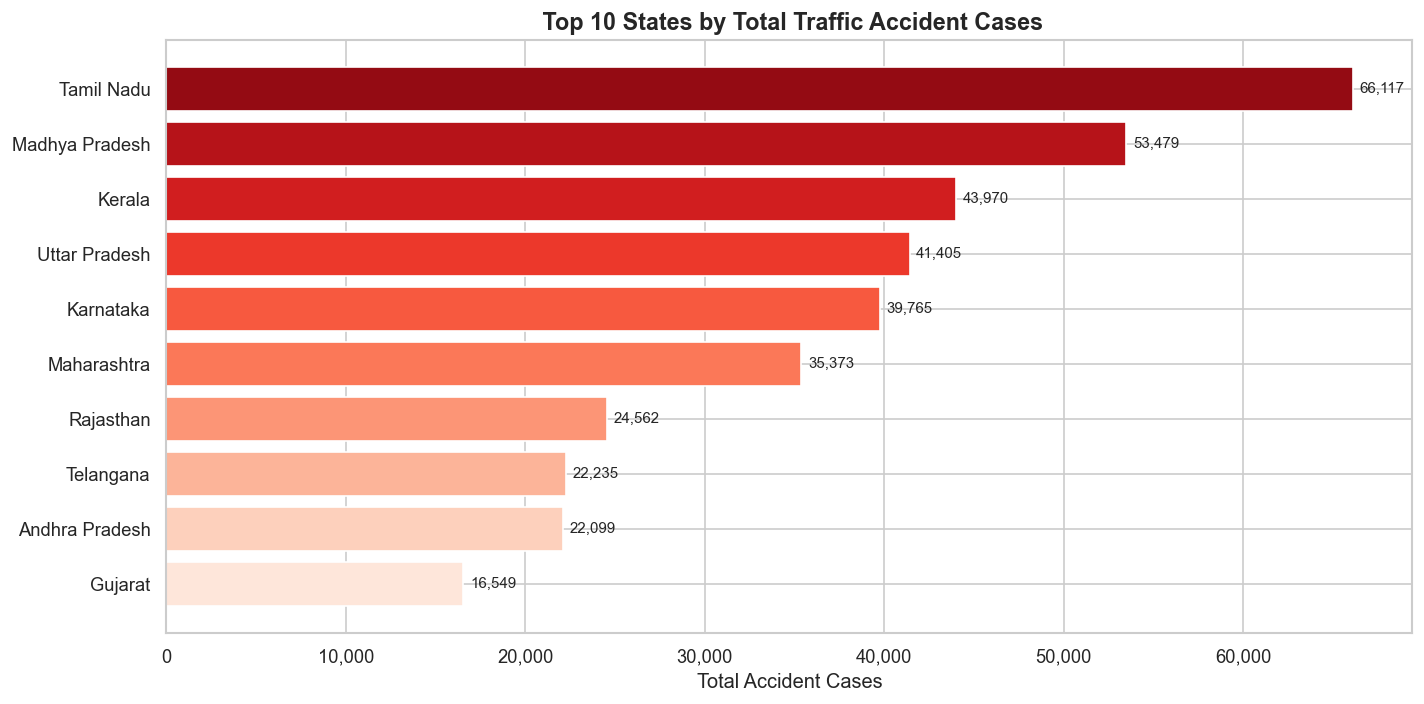

In [32]:
top10_states = df_states.nlargest(10, 'Total Traffic Accidents - Cases')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_states['State/UT/City'],
               top10_states['Total Traffic Accidents - Cases'],
               color=sns.color_palette('Reds_r', 10))

ax.bar_label(bars,
             labels=[f"{v:,.0f}" for v in top10_states['Total Traffic Accidents - Cases']],
             padding=4, fontsize=9)
ax.set_xlabel('Total Accident Cases')
ax.set_title(' Top 10 States by Total Traffic Accident Cases', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

###  Graph 2 — Road vs Railway Cases: Grouped Bar (Matplotlib)

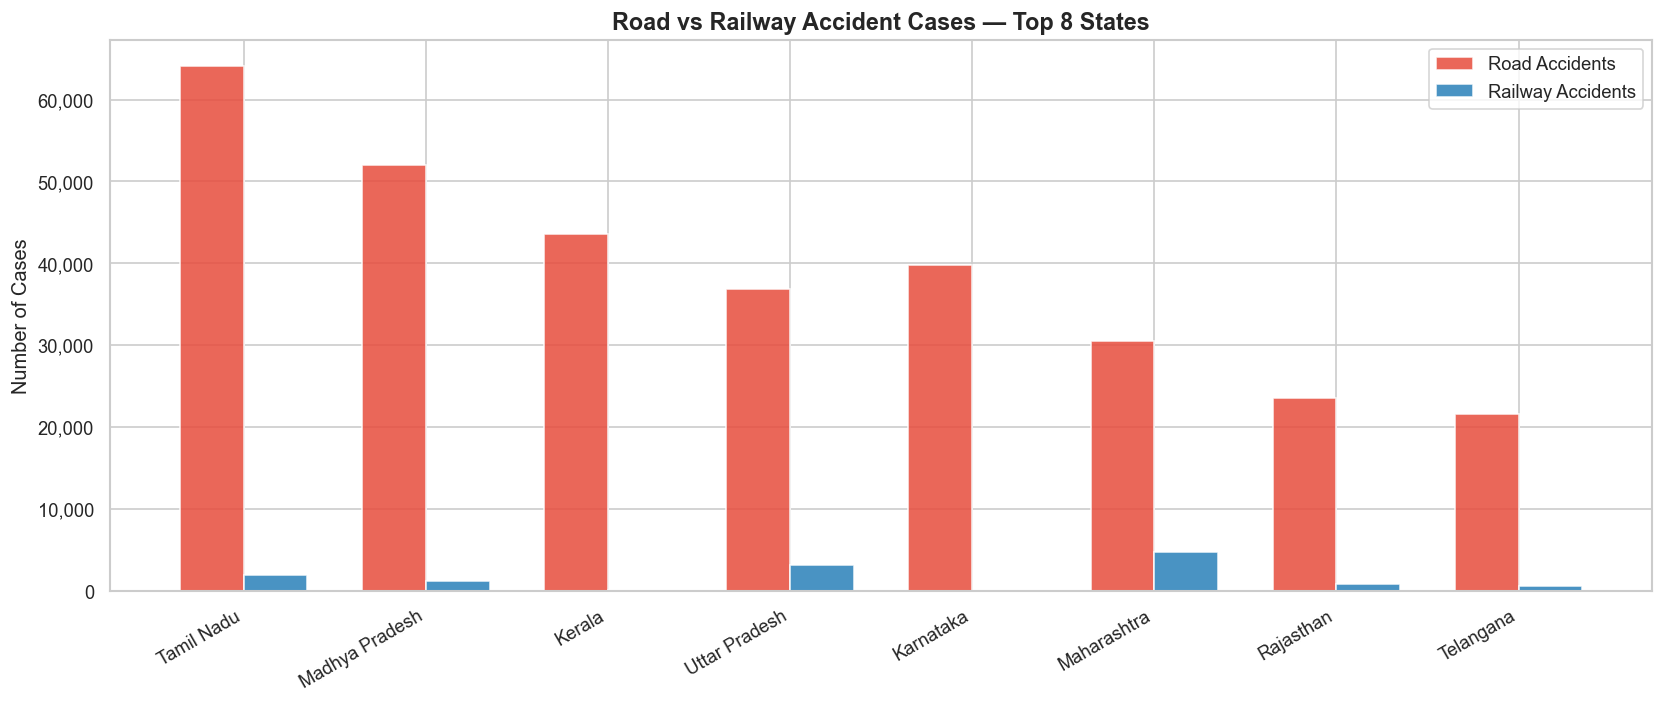

In [33]:
top8 = df_states.nlargest(8, 'Total Traffic Accidents - Cases')
x = np.arange(len(top8))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, top8['Road Accidents - Cases'],    width, label='Road Accidents',    color='#e74c3c', alpha=0.85)
ax.bar(x + width/2, top8['Railway Accidents - Cases'], width, label='Railway Accidents', color='#2980b9', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(top8['State/UT/City'], rotation=30, ha='right')
ax.set_ylabel('Number of Cases')
ax.set_title('Road vs Railway Accident Cases — Top 8 States', fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

###  Graph 3 — Pie Chart: Accident Type Share — All India (Matplotlib)

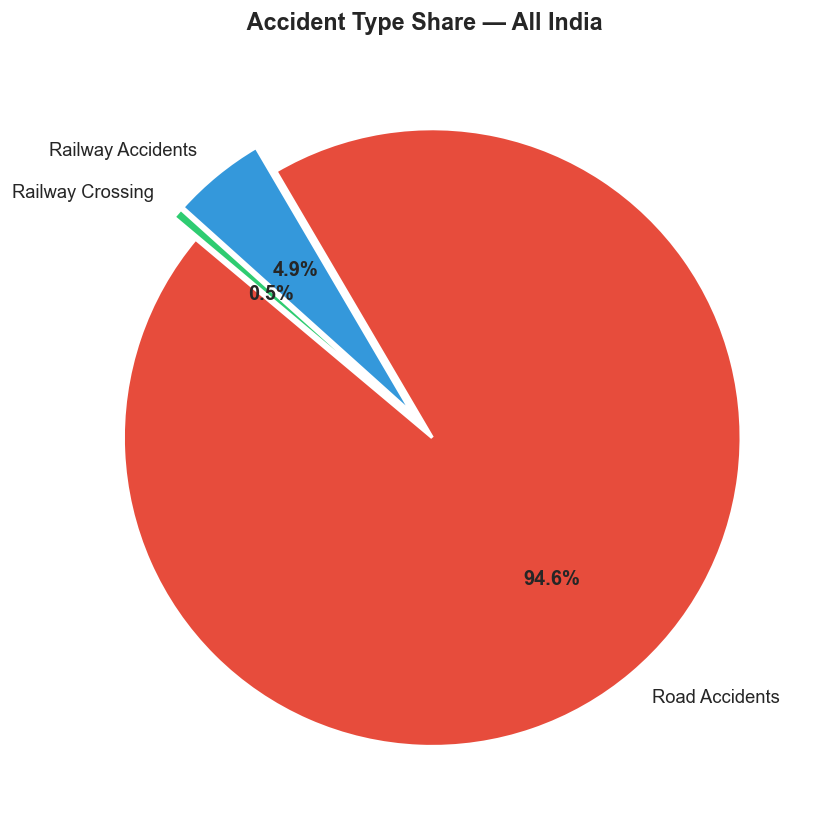

In [34]:
india = df_raw[df_raw['State/UT/City'] == 'Total (All India)'].iloc[0]

pie_vals   = [india['Road Accidents - Cases'],
              india['Railway Accidents - Cases'],
              india['Railway Crossing Accidents - Cases']]
pie_labels = ['Road Accidents', 'Railway Accidents', 'Railway Crossing']
colors_pie = ['#e74c3c', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(
    pie_vals, labels=pie_labels, autopct='%1.1f%%',
    explode=(0.05, 0.05, 0.05), colors=colors_pie,
    startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')

ax.set_title(' Accident Type Share — All India', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###  Graph 4 — KDE Plot: Distribution of Road Accident Metrics (Seaborn)

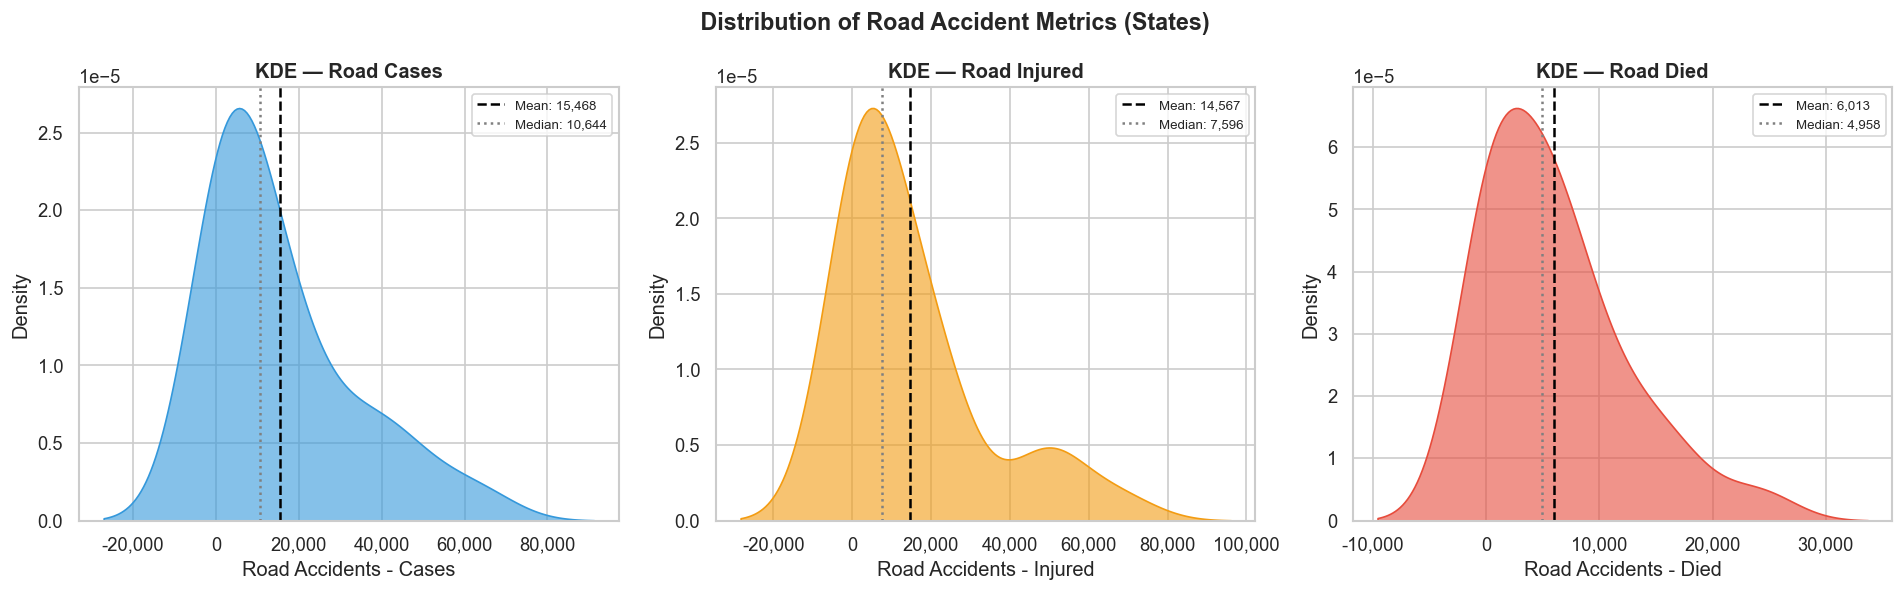

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [
    ('Road Accidents - Cases',   '#3498db', 'Cases'),
    ('Road Accidents - Injured', '#f39c12', 'Injured'),
    ('Road Accidents - Died',    '#e74c3c', 'Died')
]

for ax, (col, color, title) in zip(axes, pairs):
    sns.kdeplot(df_states[col], fill=True, color=color, ax=ax, alpha=0.6)
    ax.axvline(df_states[col].mean(),   color='black', linestyle='--',
               label=f'Mean: {df_states[col].mean():,.0f}')
    ax.axvline(df_states[col].median(), color='gray',  linestyle=':',
               label=f'Median: {df_states[col].median():,.0f}')
    ax.set_title(f'KDE — Road {title}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle(' Distribution of Road Accident Metrics (States)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Graph 5 — Box Plot: Spread of Accident Variables (Matplotlib + Seaborn)

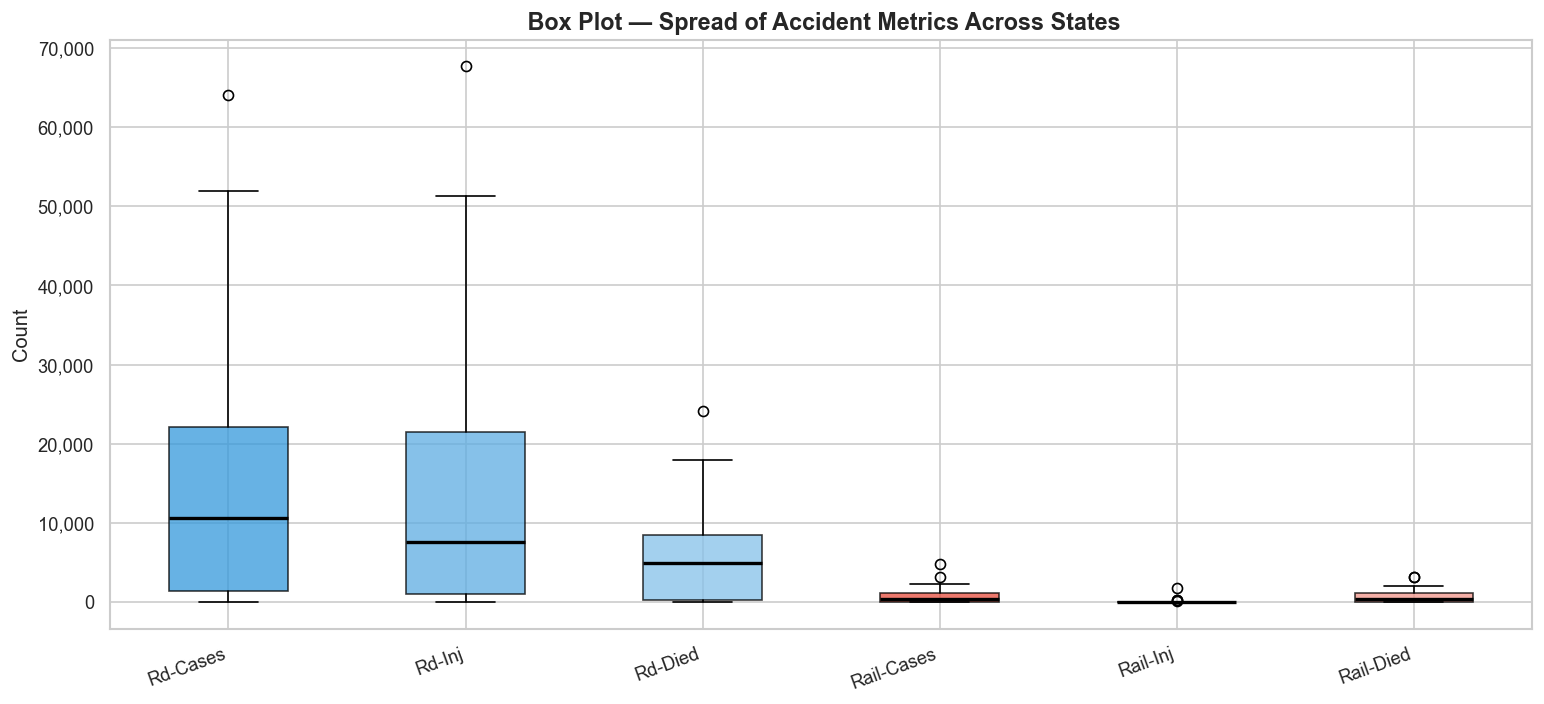

In [36]:
boxplot_cols = [
    'Road Accidents - Cases', 'Road Accidents - Injured', 'Road Accidents - Died',
    'Railway Accidents - Cases', 'Railway Accidents - Injured', 'Railway Accidents - Died'
]
short_labels = ['Rd-Cases', 'Rd-Inj', 'Rd-Died', 'Rail-Cases', 'Rail-Inj', 'Rail-Died']

fig, ax = plt.subplots(figsize=(13, 6))
box_data = [df_states[col].dropna().values for col in boxplot_cols]
bp = ax.boxplot(box_data, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))

colors_box = ['#3498db', '#5dade2', '#85c1e9', '#e74c3c', '#ec7063', '#f1948a']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticklabels(short_labels, rotation=20, ha='right')
ax.set_ylabel('Count')
ax.set_title(' Box Plot — Spread of Accident Metrics Across States', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

###  Graph 6 — Correlation Heatmap (Seaborn)

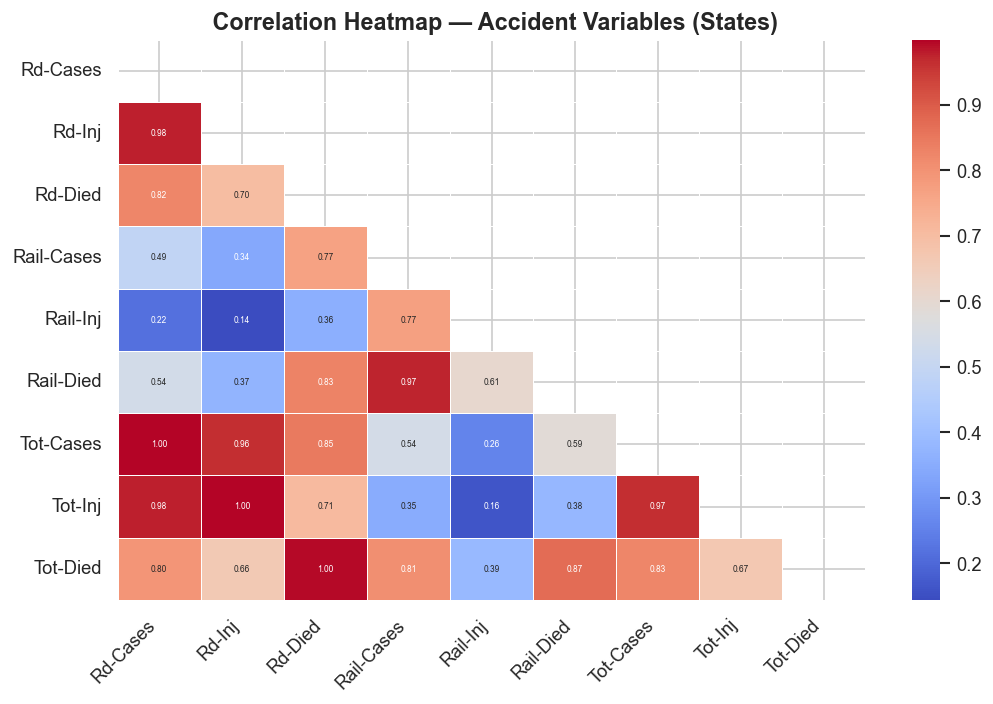

In [37]:
corr_cols = [
    'Road Accidents - Cases', 'Road Accidents - Injured', 'Road Accidents - Died',
    'Railway Accidents - Cases', 'Railway Accidents - Injured', 'Railway Accidents - Died',
    'Total Traffic Accidents - Cases', 'Total Traffic Accidents - Injured', 'Total Traffic Accidents - Died'
]
short_corr = ['Rd-Cases','Rd-Inj','Rd-Died','Rail-Cases','Rail-Inj','Rail-Died','Tot-Cases','Tot-Inj','Tot-Died']

corr = df_states[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            xticklabels=short_corr, yticklabels=short_corr,
            linewidths=0.5, ax=ax, annot_kws={'size': 5})
ax.set_title(' Correlation Heatmap — Accident Variables (States)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###  Graph 7 — Scatter Plot: Road Cases vs Deaths (Matplotlib)


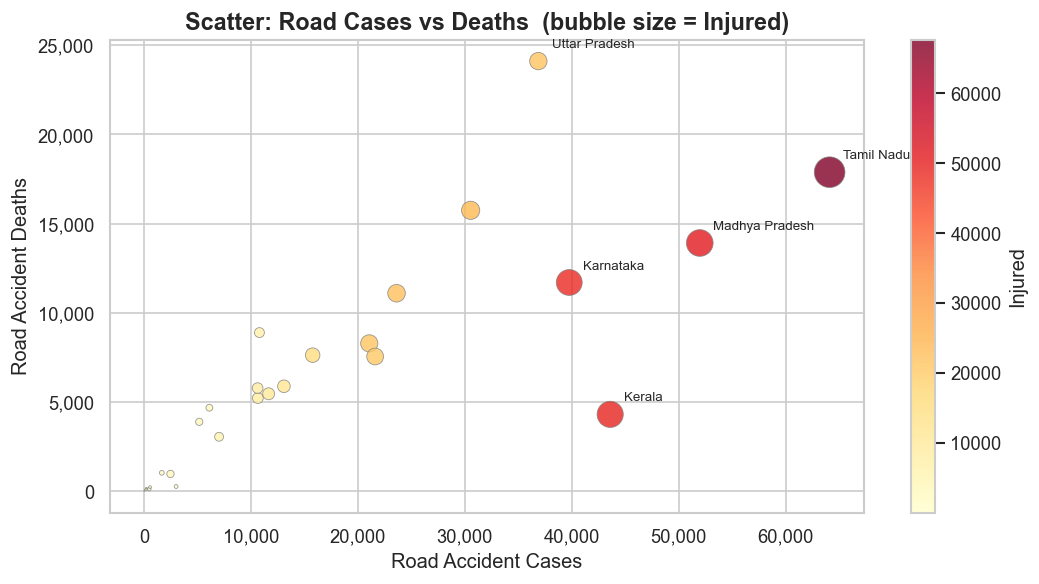

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))

sc = ax.scatter(
    df_states['Road Accidents - Cases'],
    df_states['Road Accidents - Died'],
    s=df_states['Road Accidents - Injured'] / 200,
    c=df_states['Road Accidents - Injured'],
    cmap='YlOrRd', alpha=0.8, edgecolors='gray', linewidths=0.5
)

for _, row in df_states.nlargest(5, 'Road Accidents - Cases').iterrows():
    ax.annotate(row['State/UT/City'],
                xy=(row['Road Accidents - Cases'], row['Road Accidents - Died']),
                xytext=(8, 8), textcoords='offset points', fontsize=8)

plt.colorbar(sc, ax=ax, label='Injured')
ax.set_xlabel('Road Accident Cases')
ax.set_ylabel('Road Accident Deaths')
ax.set_title('Scatter: Road Cases vs Deaths  (bubble size = Injured)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

###  Graph 8 — Outlier Detection: IQR Method (Unit IV)

Q1=1,399 | Q3=22,119 | IQR=20,720
Lower Bound=-29,681 | Upper Bound=53,199
Outlier States (1):
State/UT/City  Road Accidents - Cases
   Tamil Nadu                   64105


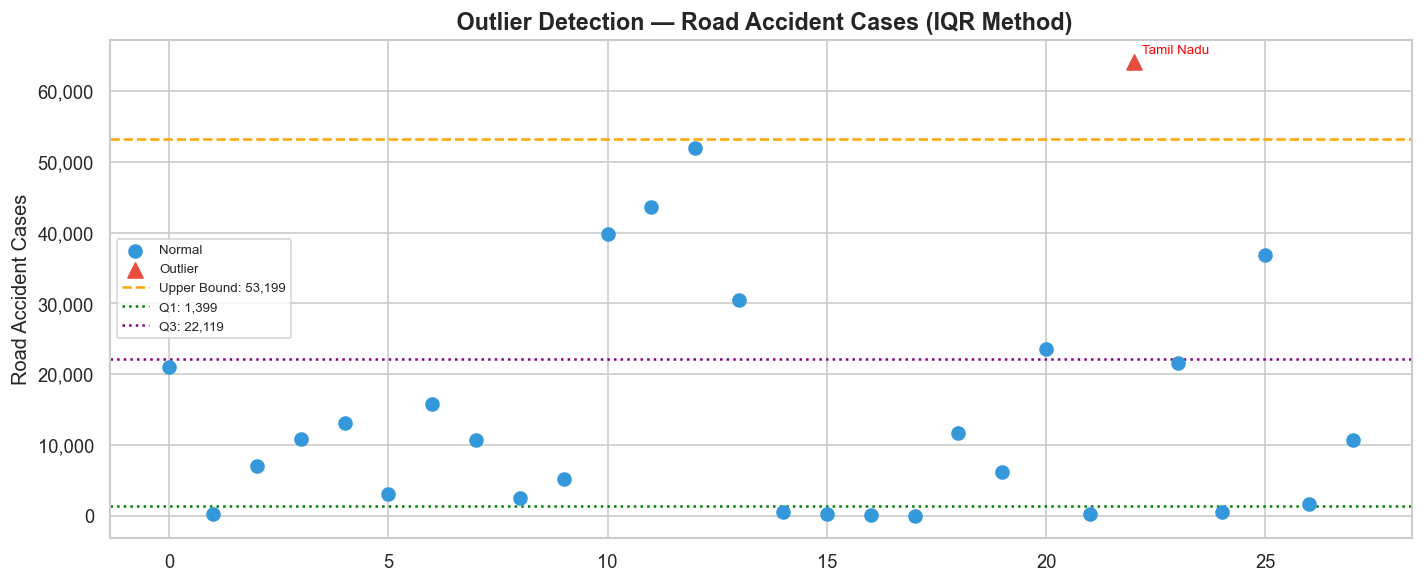

In [39]:
col = 'Road Accidents - Cases'

Q1  = df_states[col].quantile(0.25)
Q3  = df_states[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers    = df_states[df_states[col] > upper]
non_outlier = df_states[df_states[col] <= upper]

print(f'Q1={Q1:,.0f} | Q3={Q3:,.0f} | IQR={IQR:,.0f}')
print(f'Lower Bound={lower:,.0f} | Upper Bound={upper:,.0f}')
print(f'Outlier States ({len(outliers)}):')
print(outliers[['State/UT/City', col]].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(non_outlier.index, non_outlier[col], color='#3498db', label='Normal',  s=60, zorder=3)
ax.scatter(outliers.index,    outliers[col],    color='#e74c3c', label='Outlier', s=80, zorder=4, marker='^')

ax.axhline(upper, color='orange', linestyle='--', label=f'Upper Bound: {upper:,.0f}')
ax.axhline(Q1,    color='green',  linestyle=':',  label=f'Q1: {Q1:,.0f}')
ax.axhline(Q3,    color='purple', linestyle=':',  label=f'Q3: {Q3:,.0f}')

for _, row in outliers.iterrows():
    ax.annotate(row['State/UT/City'], xy=(row.name, row[col]),
                xytext=(5, 5), textcoords='offset points', fontsize=8, color='red')

ax.set_ylabel('Road Accident Cases')
ax.set_title(' Outlier Detection — Road Accident Cases (IQR Method)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

###  Graph 9 — Violin Plot: Road Accident Distribution by Category (Seaborn)

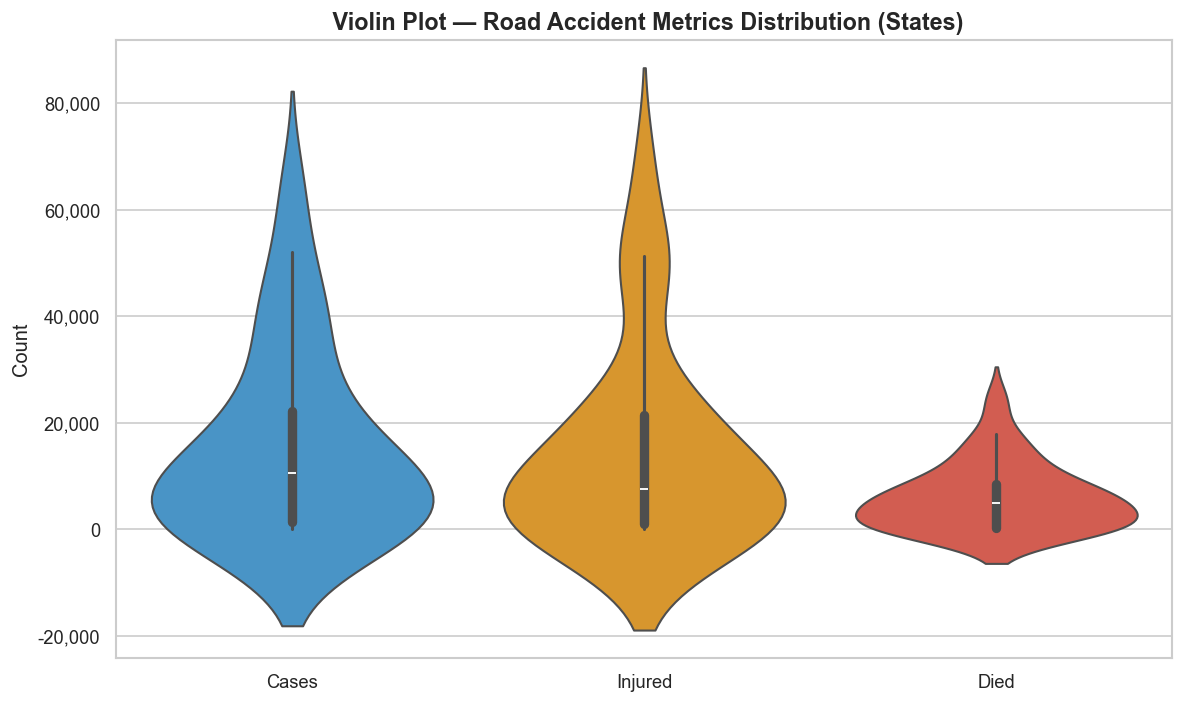

In [40]:
violin_data = pd.melt(
    df_states[['Road Accidents - Cases', 'Road Accidents - Injured', 'Road Accidents - Died']],
    var_name='Metric', value_name='Count'
)
violin_data['Metric'] = violin_data['Metric'].str.replace('Road Accidents - ', '')

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=violin_data, x='Metric', y='Count',
               palette=['#3498db', '#f39c12', '#e74c3c'], ax=ax, inner='box')
ax.set_title(' Violin Plot — Road Accident Metrics Distribution (States)', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

### Graph 10 — Top 10 Cities: Road Accident Cases (Seaborn Barplot)

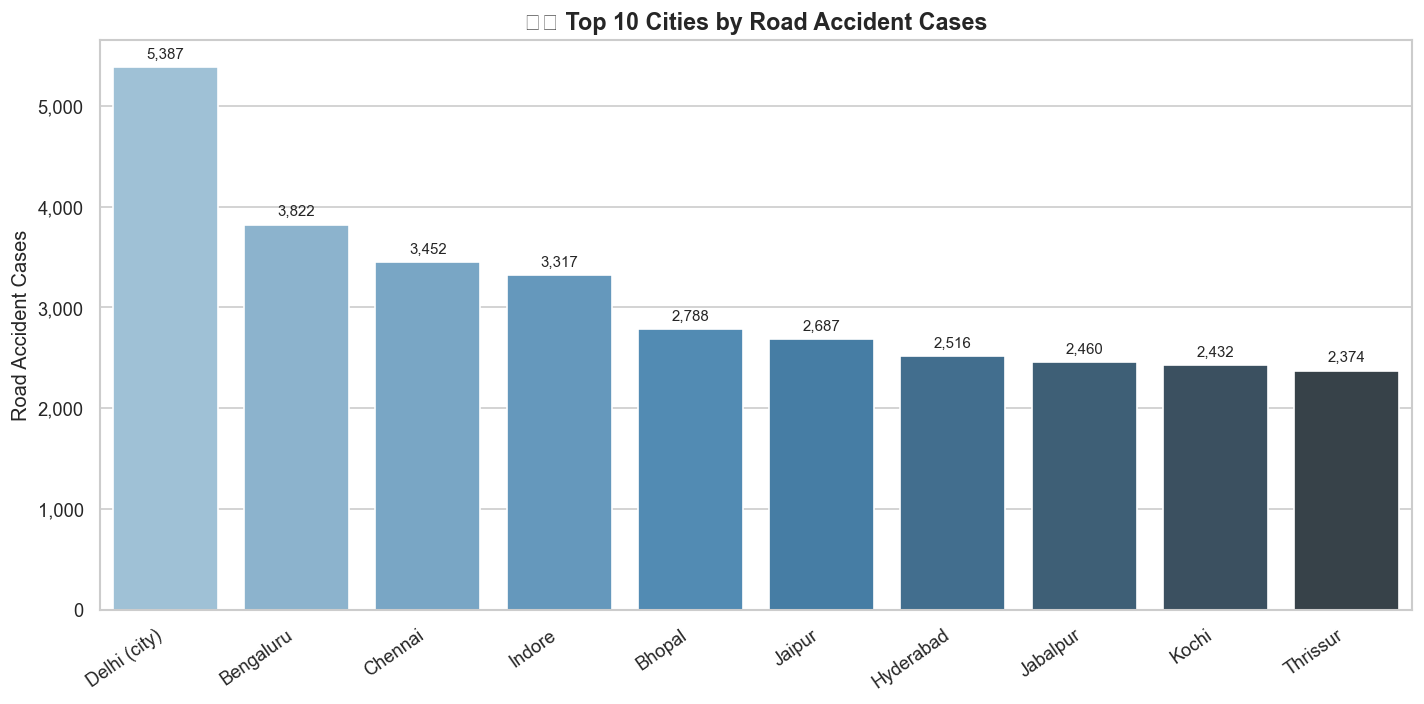

In [41]:
top10_cities = df_cities.nlargest(10, 'Road Accidents - Cases')

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top10_cities, x='State/UT/City', y='Road Accidents - Cases',
            palette='Blues_d', ax=ax)


for bar, val in zip(ax.patches, top10_cities['Road Accidents - Cases']):
    if bar is None:
        continue
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + ax.get_ylim()[1] * 0.01,
        f"{val:,.0f}",
        ha='center', va='bottom', fontsize=9
    )

ax.set_xticklabels(top10_cities['State/UT/City'], rotation=35, ha='right')
ax.set_ylabel('Road Accident Cases')
ax.set_xlabel('')
ax.set_title('🏙️ Top 10 Cities by Road Accident Cases', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

###  Graph 11 — Pair Plot: Key Accident Metrics (Seaborn)

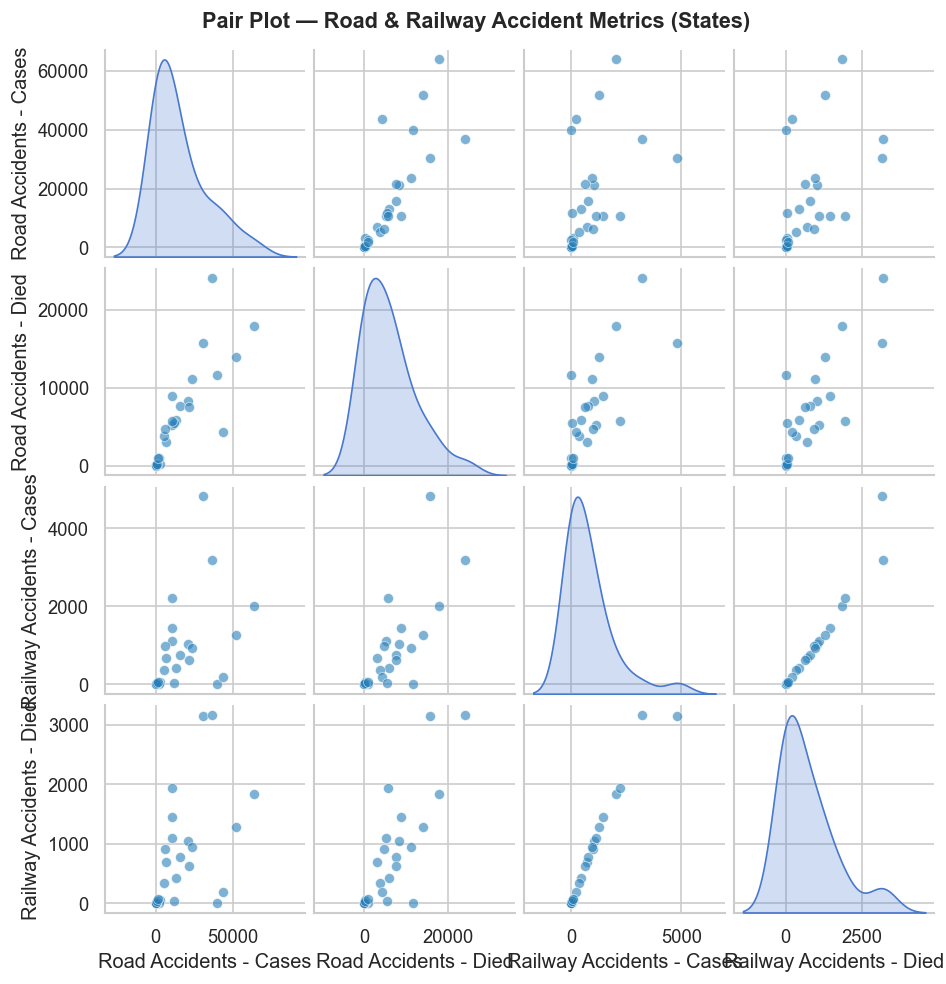

In [42]:
pair_cols = [
    'Road Accidents - Cases', 'Road Accidents - Died',
    'Railway Accidents - Cases', 'Railway Accidents - Died'
]
pg = sns.pairplot(df_states[pair_cols].dropna(),
                  diag_kind='kde',
                  plot_kws={'alpha': 0.6, 'color': '#2980b9'},
                  height=2.0,        
                  aspect=1.0)        

pg.fig.suptitle(' Pair Plot — Road & Railway Accident Metrics (States)', y=1.02,
                fontsize=13, fontweight='bold')
plt.show()

###  Graph 12 — Fatality Rate: Most Dangerous States (Matplotlib)

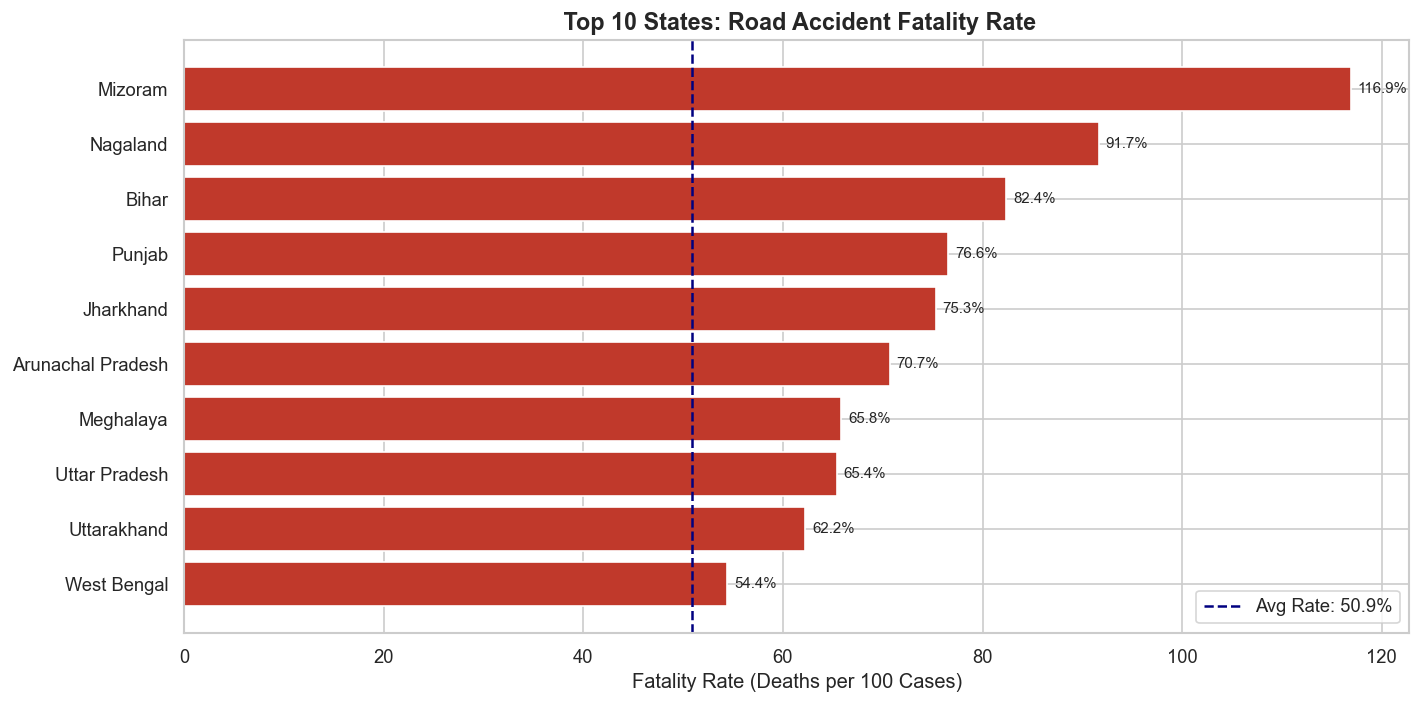

In [43]:
df_states['Road Fatality Rate (%)'] = (
    df_states['Road Accidents - Died'] /
    df_states['Road Accidents - Cases'].replace(0, np.nan) * 100
).round(2)

top10_fatal = df_states.nlargest(10, 'Road Fatality Rate (%)').sort_values('Road Fatality Rate (%)')
avg_rate    = df_states['Road Fatality Rate (%)'].mean()

colors_f = ['#c0392b' if v > 30 else '#e67e22' if v > 20 else '#f1c40f'
            for v in top10_fatal['Road Fatality Rate (%)']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_fatal['State/UT/City'], top10_fatal['Road Fatality Rate (%)'], color=colors_f)
ax.bar_label(bars,
             labels=[f"{v:.1f}%" for v in top10_fatal['Road Fatality Rate (%)']],
             padding=4, fontsize=9)
ax.axvline(avg_rate, color='navy', linestyle='--', label=f'Avg Rate: {avg_rate:.1f}%')
ax.set_xlabel('Fatality Rate (Deaths per 100 Cases)')
ax.set_title(' Top 10 States: Road Accident Fatality Rate', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

##  Cell — Covariance Matrix

In [44]:
cov_cols = ['Road Accidents - Cases', 'Road Accidents - Died', 'Railway Accidents - Cases']
print('=== Covariance Matrix ===')
print(df_states[cov_cols].cov().round(2))

print('\n=== Correlation Matrix ===')
print(df_states[cov_cols].corr().round(4))

=== Covariance Matrix ===
                           Road Accidents - Cases  Road Accidents - Died  \
Road Accidents - Cases               3.105903e+08            90362901.94   
Road Accidents - Died                9.036290e+07            38773058.54   
Railway Accidents - Cases            9.761218e+06             5387190.88   

                           Railway Accidents - Cases  
Road Accidents - Cases                    9761217.77  
Road Accidents - Died                     5387190.88  
Railway Accidents - Cases                 1274356.62  

=== Correlation Matrix ===
                           Road Accidents - Cases  Road Accidents - Died  \
Road Accidents - Cases                     1.0000                 0.8234   
Road Accidents - Died                      0.8234                 1.0000   
Railway Accidents - Cases                  0.4906                 0.7664   

                           Railway Accidents - Cases  
Road Accidents - Cases                        0.4906  
Road A

##  Cell — Outlier Detection: Z-Score Method


=== Outliers detected via Z-Score (|z| > 2) ===
 State/UT/City  Road Accidents - Cases  Z_Score
Madhya Pradesh                   51965 2.070905
    Tamil Nadu                   64105 2.759755


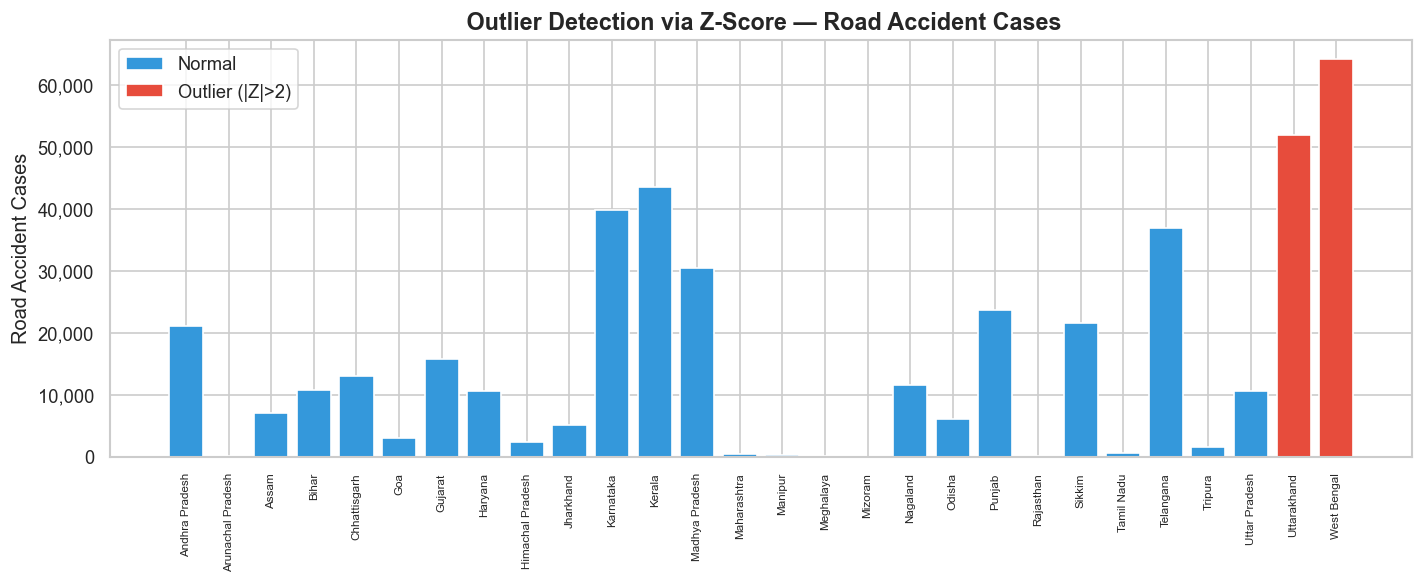

In [45]:
col = 'Road Accidents - Cases'
mean = df_states[col].mean()
std  = df_states[col].std()

df_states['Z_Score'] = (df_states[col] - mean) / std

outliers_z = df_states[df_states['Z_Score'].abs() > 2]
print('=== Outliers detected via Z-Score (|z| > 2) ===')
print(outliers_z[['State/UT/City', col, 'Z_Score']].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
normal_z  = df_states[df_states['Z_Score'].abs() <= 2]
outlier_z = df_states[df_states['Z_Score'].abs() >  2]

ax.bar(normal_z['State/UT/City'],  normal_z[col],  color='#3498db', label='Normal')
ax.bar(outlier_z['State/UT/City'], outlier_z[col], color='#e74c3c', label='Outlier (|Z|>2)')
ax.set_xticklabels(df_states['State/UT/City'], rotation=90, fontsize=7)
ax.set_ylabel('Road Accident Cases')
ax.set_title(' Outlier Detection via Z-Score — Road Accident Cases', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

##  Final Cell — Key Insights Summary

In [46]:
india = df_raw[df_raw['State/UT/City'] == 'Total (All India)'].iloc[0]
fatality_pct = india['Road Accidents - Died'] / india['Road Accidents - Cases'] * 100

print('=' * 62)
print('       INDIA TRAFFIC ACCIDENTS — EDA SUMMARY')
print('=' * 62)
print(f"  Total Road Accident Cases         : {india['Road Accidents - Cases']:>10,.0f}")
print(f"  Total Road Deaths                 : {india['Road Accidents - Died']:>10,.0f}")
print(f"  Total Road Injured                : {india['Road Accidents - Injured']:>10,.0f}")
print(f"  Total Railway Cases               : {india['Railway Accidents - Cases']:>10,.0f}")
print(f"  Overall Road Fatality Rate        : {fatality_pct:>10.2f}%")
print(f"  State — Most Road Cases           : {df_states.loc[df_states['Road Accidents - Cases'].idxmax(), 'State/UT/City']}")
print(f"  State — Most Road Deaths          : {df_states.loc[df_states['Road Accidents - Died'].idxmax(), 'State/UT/City']}")
print(f"  City  — Most Road Cases           : {df_cities.loc[df_cities['Road Accidents - Cases'].idxmax(), 'State/UT/City']}")
print(f"  Mean Road Cases per State         : {df_states['Road Accidents - Cases'].mean():>10,.1f}")
print(f"  Median Road Cases per State       : {df_states['Road Accidents - Cases'].median():>10,.1f}")
print(f"  Std Dev Road Cases                : {df_states['Road Accidents - Cases'].std():>10,.1f}")
print('=' * 62)

       INDIA TRAFFIC ACCIDENTS — EDA SUMMARY
  Total Road Accident Cases         :    446,768
  Total Road Deaths                 :    171,100
  Total Road Injured                :    423,158
  Total Railway Cases               :     23,139
  Overall Road Fatality Rate        :      38.30%
  State — Most Road Cases           : Tamil Nadu
  State — Most Road Deaths          : Uttar Pradesh
  City  — Most Road Cases           : Delhi (city)
  Mean Road Cases per State         :   15,468.2
  Median Road Cases per State       :   10,644.5
  Std Dev Road Cases                :   17,623.6


##  Unit V — Statistical Analysis: Hypothesis Testing

In [47]:
from scipy import stats

col = 'Road Accidents - Cases'
stat, p_value = stats.shapiro(df_states[col])
print("=== Shapiro-Wilk Normality Test ===")
print(f"Statistic: {stat:.4f} | p-value: {p_value:.4f}")
print("Normal distribution:", "YES" if p_value > 0.05 else "NO (skewed data)")

median_inj = df_states['Road Accidents - Injured'].median()
high_inj = df_states[df_states['Road Accidents - Injured'] >= median_inj]['Road Accidents - Died']
low_inj  = df_states[df_states['Road Accidents - Injured'] <  median_inj]['Road Accidents - Died']

t_stat, p_val = stats.ttest_ind(high_inj, low_inj)
print("\n=== T-Test: Deaths in High vs Low Injury States ===")
print(f"t-statistic: {t_stat:.4f} | p-value: {p_val:.4f}")
print("Significant difference:", "YES" if p_val < 0.05 else "NO")

median_cases = df_states['Road Accidents - Cases'].median()
df_states['Accident_Level'] = df_states['Road Accidents - Cases'].apply(
    lambda x: 'High' if x >= median_cases else 'Low'
)
df_states['Death_Level'] = df_states['Road Accidents - Died'].apply(
    lambda x: 'High' if x >= df_states['Road Accidents - Died'].median() else 'Low'
)
contingency = pd.crosstab(df_states['Accident_Level'], df_states['Death_Level'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print("\n=== Chi-Square Test: Accident Level vs Death Level ===")
print(f"Chi2: {chi2:.4f} | p-value: {p_chi:.4f} | DOF: {dof}")
print("Association exists:", "YES" if p_chi < 0.05 else "NO")

=== Shapiro-Wilk Normality Test ===
Statistic: 0.8297 | p-value: 0.0004
Normal distribution: NO (skewed data)

=== T-Test: Deaths in High vs Low Injury States ===
t-statistic: 5.0872 | p-value: 0.0000
Significant difference: YES

=== Chi-Square Test: Accident Level vs Death Level ===
Chi2: 17.2857 | p-value: 0.0000 | DOF: 1
Association exists: YES


##  Unit VI — Machine Learning: Linear Regression (CRISP-DM Framework)

=== Linear Regression: Road Cases → Road Deaths ===
Coefficient (slope) : 0.2582
Intercept           : 1620.77
R² Score            : 0.5825
Mean Squared Error  : 29,323,049.69

For every 1 extra road accident case, approx. 0.2582 additional deaths are predicted.


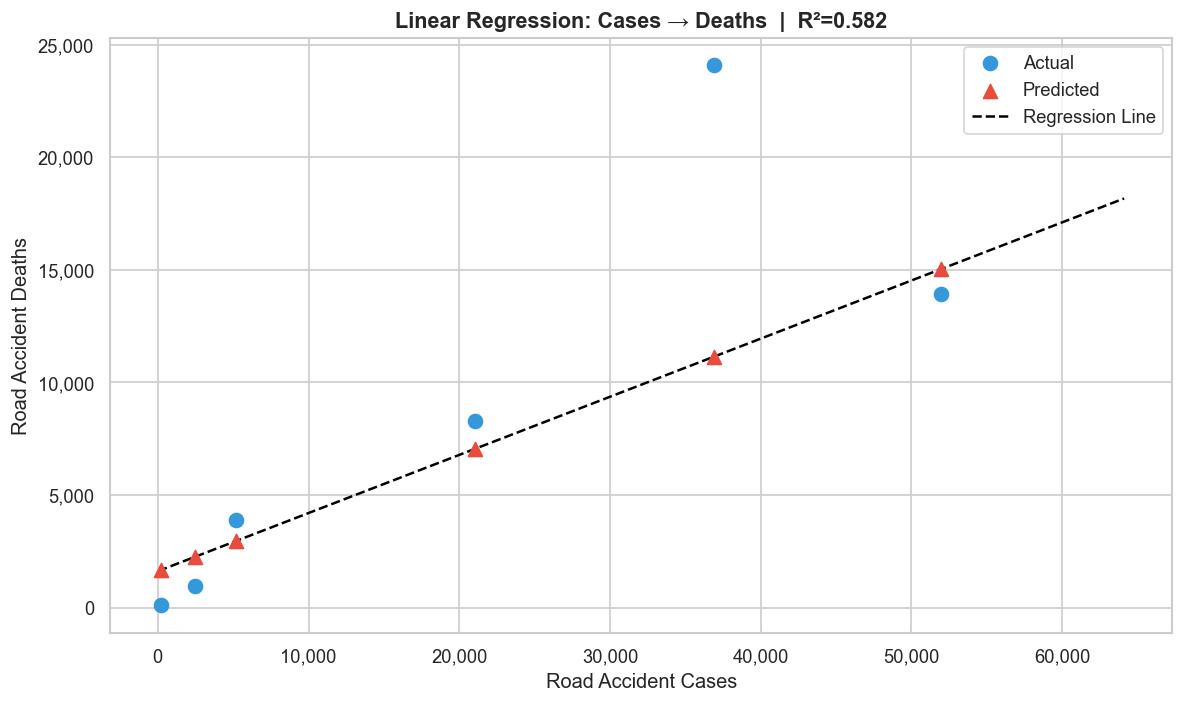

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = df_states[['Road Accidents - Cases']].dropna()
y = df_states.loc[X.index, 'Road Accidents - Died']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2  = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("=== Linear Regression: Road Cases → Road Deaths ===")
print(f"Coefficient (slope) : {model.coef_[0]:.4f}")
print(f"Intercept           : {model.intercept_:.2f}")
print(f"R² Score            : {r2:.4f}")
print(f"Mean Squared Error  : {mse:,.2f}")
print(f"\nFor every 1 extra road accident case, approx. {model.coef_[0]:.4f} additional deaths are predicted.")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_test, y_test, color='#3498db', label='Actual', s=70, zorder=3)
ax.scatter(X_test, y_pred, color='#e74c3c', label='Predicted', marker='^', s=70, zorder=4)

x_line = np.linspace(X['Road Accidents - Cases'].min(), X['Road Accidents - Cases'].max(), 100).reshape(-1,1)
ax.plot(x_line, model.predict(x_line), color='black', linewidth=1.5, linestyle='--', label='Regression Line')

ax.set_xlabel('Road Accident Cases')
ax.set_ylabel('Road Accident Deaths')
ax.set_title(f'Linear Regression: Cases → Deaths  |  R²={r2:.3f}', fontsize=13, fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()